In [1]:
import os

if 'KERAS_BACKEND' not in os.environ:
    os.environ['KERAS_BACKEND'] = 'jax'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import bayesflow as bf

from ssms.basic_simulators.simulator import simulator as ssm_sim

INFO:bayesflow:Using backend 'jax'


# A Minimal Bayesian Workflow for Cognitive Modeling with SSMS and BayesFlow

 In this tutorial, we demonstrate a [principled Bayesian workflow](https://betanalpha.github.io/assets/case_studies/principled_bayesian_workflow.html) for developing and applying cognitive models with Amortized Bayesian Inference (ABI). We use Sequential Sampling Models (SSMs) to represent and simulate a cognitive process. The simulation is given by the [Sequential Sampling Model Simulators (SSMS)](https://lnccbrown.github.io/ssm-simulators/api/ssms/) package, the backbone for the [Hierarchical Sequential Sampling Model (HSSM) toolbox](https://lnccbrown.github.io/HSSM/). We use [BayesFlow](https://bayesflow.org)'s powerful generative neural networks and comprehensive diagnostics utilities to train on the simulated data and estimate model parameters.

## Simulator

We start with the basic simulator from the HSSM toolbox. We start with the simplest simulator available: the classic drift-diffusion model (DDM) with 4 parameters:

* Drift rate ($v$),
* Boundary ($a$),
* Initial bias ($z$), and
* Non-decision time ($t$).

These are the parameters that we sample as priors (to be specified below) and used as inputs. For each sampled parameters, we specify `num_trials` for the simulation. The resulting collection of reaction times (RTs) and choices are our simulation outputs. These outputs are used as our dataset for training and validating the neural approximator.

In [3]:
def ddm_simulator(v: float, a: float, z: float, tau: float, num_trials: int = 100):
    """
    A simple wrapper of the standard Drift-Diffusion Model (DDM) simulator using the SSMS package. 
    It will simulate `num_trials` responses of synthetic participant with the provided parameters.

    Parameters
    ----------
    v : float, default: None
        User-defined drift rate.
    a : float, default: None
        User-defined decision boundary threshold.
    z : float, default: None
        User-defined initial decision bias.
    tau : float, default: None
        User-defined non-decision time (NDT).
    num_trials : int, default: 100
        Number of simulated trials for the synthetic participant.

    Returns
    -------
    A dictionary of the following simulated data of shape (num_samples, 1) each:
    - rts: reaction times
    - choices: Choice decision outcomes
    """

    # Directly simulate using SSMS
    ddm_sim = ssm_sim(model="ddm", theta=dict(v=v, a=a, z=z, t=tau), n_samples=num_trials)

    rts = ddm_sim['rts']
    choices = ddm_sim['choices']

    return dict(rts=rts, choices=choices)

In [4]:
# Test the simulator generating a single synthetic participant
sim = ddm_simulator(v=0.5, a=1.0, z=0.5, tau=0.7)
print(sim['rts'].shape)
print(sim['choices'].shape)

(100, 1)
(100, 1)


## Priors

Next, we will sample the DDM parameters from our simulator as priors from some distributions. Below, we specify the prior distributions:

\begin{equation}
v \sim \mathrm{Gamma}(2, 0.8), \; a \sim \mathrm{Gamma}(10, 0.2), \; z \sim \mathrm{Beta}(2, 2), \; t \sim \mathrm{Gamma}(1.5, 0.2).
\end{equation}

In [5]:
def priors(rng=None):
    """
    Defines the priors for all parameters in the standard DDM.

    Parameters
    ----------
    rng : np.random.RandomState, default: None
        Random number generator.

    Returns
    -------
    A dictionary of all standard DDM parameters:
    - v: drift rate
    - a: decision boundary threshold
    - z: initial decision bias
    - tau: non-decision time
    """
    if rng is None:
        rng = np.random.default_rng()

    drift = rng.gamma(2, 0.8)
    threshold = rng.gamma(10, 0.2)
    bias = rng.beta(3, 3)
    ndt = rng.gamma(1.5, 0.2)

    return dict(v=drift, a=threshold, z=bias, tau=ndt)

In [6]:
# We can inspect the sampled parameter dictionary
theta = priors()
theta

{'v': 2.7345767208976666,
 'a': 2.5215899734151703,
 'z': 0.28238836809392276,
 'tau': 0.10000949038238789}

## Putting everything together

After specifying the simulator and priors, we would wrap them together using BayesFlow's `make_simulator` function. Under the hood, BayesFlow unpacks the dictionary of samples from `priors` and uses them as inputs for the `ddm_simulator`. You can chain an arbitrary number of functions in the same manner.

In [7]:
simulator = bf.make_simulator([priors, ddm_simulator])

Once we have the `simulator`, we can specify a batch size and use it to generate samples, just like what we did from `ddm_simulator` itself.

In [8]:
batch_size = 10
draws = simulator.sample(batch_size)

The sample draws consists of both the simulator outputs from `ddm_simulator` and the prior samples from `priors`. Because we specified a batch size, the draws would have shapes `(batch_size, ...)`.

In [9]:
print(draws['v'].shape)
print(draws['tau'].shape)
print(draws['rts'].shape)
print(draws['choices'].shape)

(10, 1)
(10, 1)
(10, 100, 1)
(10, 100, 1)


## Prior Predictive Checks

To make sure that we are sampling the priors properly, BayesFlow has a pretty nice visual inspection in its `diagnostics` module that allows us to observe the samples directly as the respective sample distribution for each parameter.

In [10]:
prior_samples = simulator.simulators[0].sample(500)

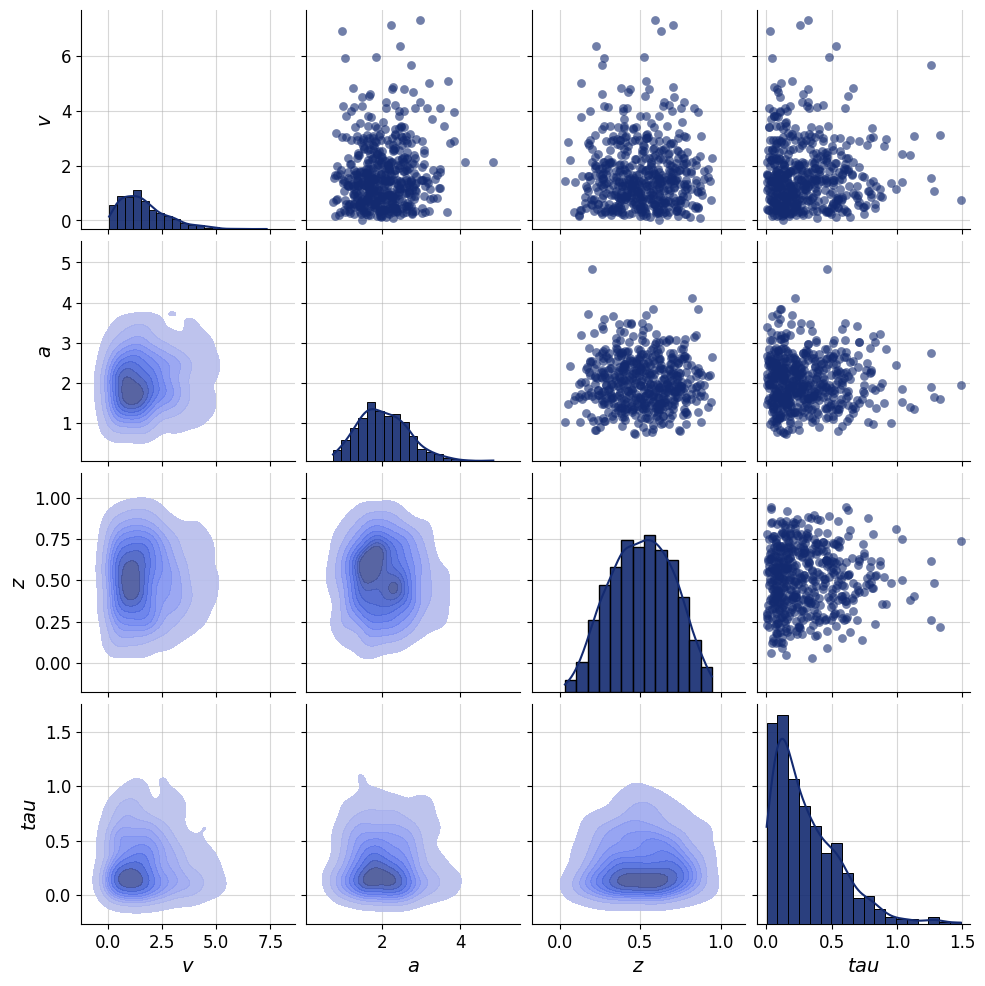

In [11]:
prior_grid = bf.diagnostics.plots.pairs_samples(samples=prior_samples, variable_names=[r'$v$', r'$a$', r'$z$', r'$tau$'])

Furthermore, to ensure that the simulator produces reliable results, we can also visualize the outputs from `simulator` samples by their individual draw.

In [12]:
n_rows = 2
n_cols = batch_size // n_rows

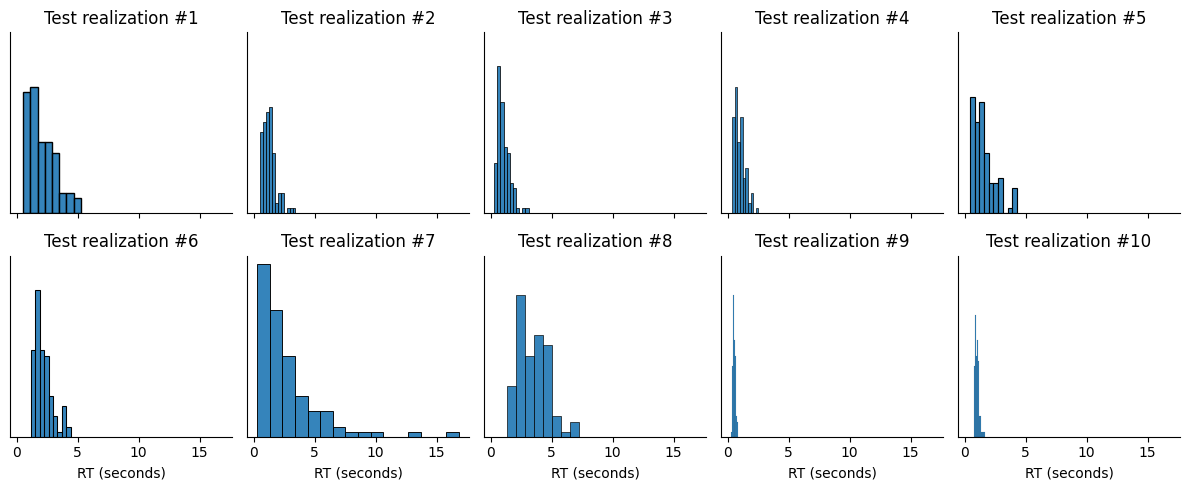

In [13]:
fig, axarr = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 5), sharey=True, sharex=True)

for i, ax in enumerate(axarr.flat):
    sns.histplot(data=draws['rts'][i], ax=ax, color="#132a70", legend=None, alpha=0.9)
    if i > n_cols - 1:
        ax.set_xlabel("RT (seconds)")
    ax.set_ylabel("")
    ax.set_yticks([])
    sns.despine(ax=ax)
    ax.set_title(f"Test realization #{i+1}")
fig.tight_layout()

## Adapter

To make sure that the simulated data and priors all friendly to the neural approximator, we use BayesFlow's `Adapter` to transform the data into summary variables and inference variables.

In a nutshell, from the perspective of the neural estimator:

* **Summary variables** are simulated data, and
* **Inference variables** are the parameters.

In [14]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype('float64', 'float32')
    .concatenate(['v', 'a', 'z', 'tau'], into="inference_variables")
    .constrain("inference_variables", lower=0)
    .concatenate(['rts', 'choices'], into="summary_variables")
)

Here is what the individual elements in `adapter` means:

* `.convert_dtype()` converts all samples to a data type that the neural estimator likes. Typically, this is `float32`.
* `.concatenate()` bundles the sampled parameters together as `inference_variables`, and the simulated response times and choices as `summary_variables`.
* `.constrain()` informs the networks that the parameter has bounds, making the learning task easier.

Below, we can visualize the `adapter` workflow to make the data preprocessing steps transparent.

In [15]:
adapter

Adapter([0: ConvertDType -> 1: Concatenate(['v', 'a', 'z', 'tau'] -> 'inference_variables') -> 2: Constrain -> 3: Concatenate(['rts', 'choices'] -> 'summary_variables')])

We can inspect the transformed data after wrapping the simulation in the adapter to process.

In [18]:
adapted_draws = adapter(simulator.sample(3))

In [19]:
# This step makes sure that the samples are bundled properly as summary variables and inference variables
print("Shape of summary variables", adapted_draws['summary_variables'].shape)
print("Shape of inference variables", adapted_draws['inference_variables'].shape)

Shape of summary variables (3, 100, 2)
Shape of inference variables (3, 4)


## Neural estimator

The neural estimator is essentially a two-stage generative neural network consisting of a **summary network** and an **inference network**.

* **Summary network** takes the simulated data (*summary variables*) directly as inputs, and compress it into some latent summary statistics,
* **Inference network** takes the summary statistics as inputs, and infers the parameters (*inference variables*) from them.

### Summary Network

Since our likelihood generates data exchangeably, we need to respect the associated permutation invariance. The latter implies that the probability distribution of a sequence of observations remains the same regardless of the order in which the observations appear. For that, we will use a tiny `SetTransformer` that will be fast to training on a CPU.

This network will take (at least) 3D tensors of shape `(batch_size, num_obs, D)` and reduce them to 2D tensors of shape `(batch_size, summary_dim)`, where `summary_dim` is a hyperparameter to be set by the user (you). Heuristically, this number should not be lower than the number of parameters in a model. Below, we create a permutation-invariant transformer network with defult `summary_dim = 16`:

In [20]:
# Alternatively, you can also use DeepSet
summary_net = bf.networks.SetTransformer(embed_dims=(32, 32), mlp_widths=(32, 32))

### Inference Network

To actually approximate the posterior distribution, we need to define a generative neural network. Here we choose the all time favorite `CouplingFlow` that realizes a simple normalizing flow.

In [23]:
inference_net = bf.networks.CouplingFlow(depth=2, transform="spline", permutation="orthogonal")

## Workflow

BayesFlow makes everything easier by wrapping the entire amortization process into workflow objects. Here, we can simply use a `BasicWorkflow` object that bring together the simulator, the adapter, the summary network, and the inference network.

In [24]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    standardize=None
)

## Training

Using the `BasicWorkflow` object, we can generate training data and validation data for training the neural estimator. Typically, you will generate much more and possibly traing online (i.e., using on-demand simulation).

In [25]:
training_data = workflow.simulate(5000)
validation_data = workflow.simulate(300)

In [26]:
history = workflow.fit_offline(
    data=training_data,
    epochs=20,
    batch_size=32,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


INFO:bayesflow:Building on a test batch.


Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 147ms/step - loss: 5.5673 - val_loss: 4.2213
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 3.7548 - val_loss: 2.9396
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - loss: 2.6860 - val_loss: 1.9925
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 2.0744 - val_loss: 2.3361
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - loss: 1.6575 - val_loss: 1.4583
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 1.4792 - val_loss: 1.0263
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 1.1021 - val_loss: 0.8955
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - loss: 0.8731 - val_loss: 0.8297
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.8095 - val_loss: 0.7586
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.7370 - val_loss: 0.3926
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - loss: 0.5417 - val_loss: 0.7001
Epoch 12/20
157/157 ━━━━━━━━━

## Diagnostics

The `BasicWorkflow` object also gather all the diagnostics functionality that BayesFlow has to offer.

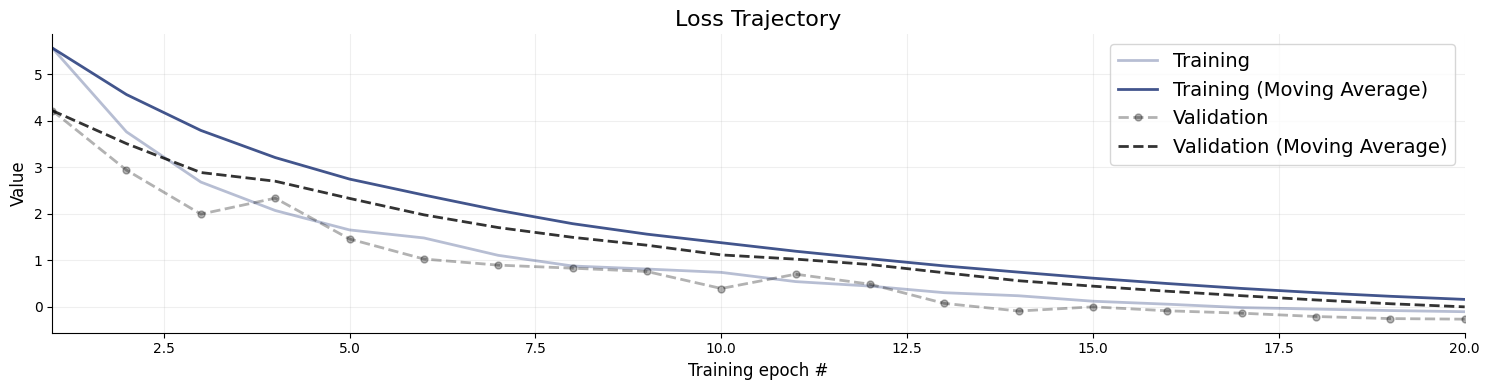

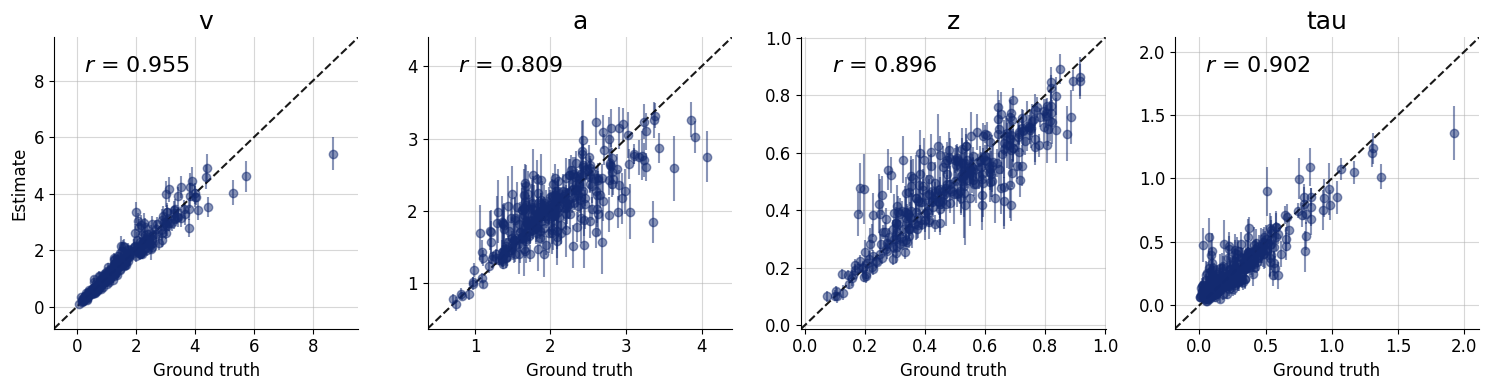

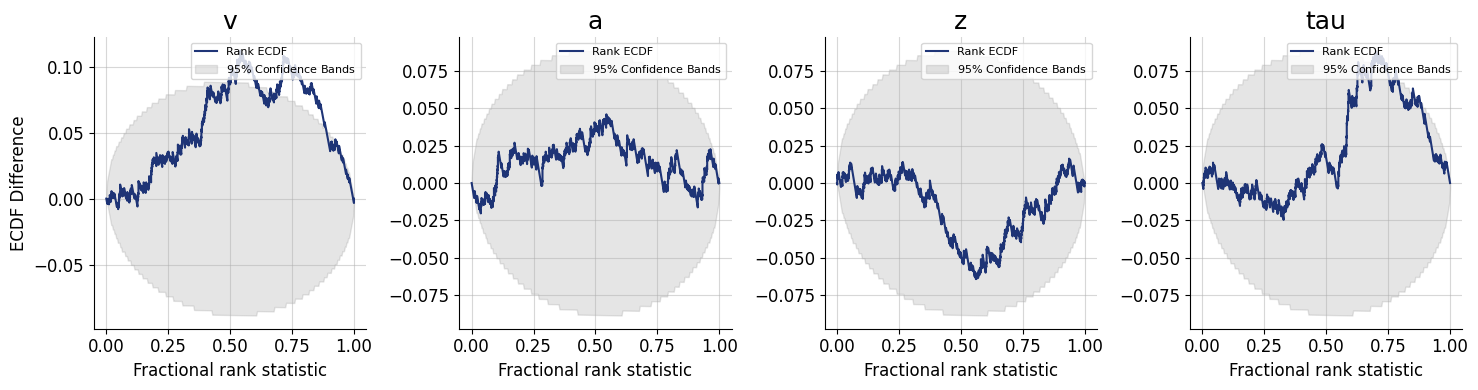

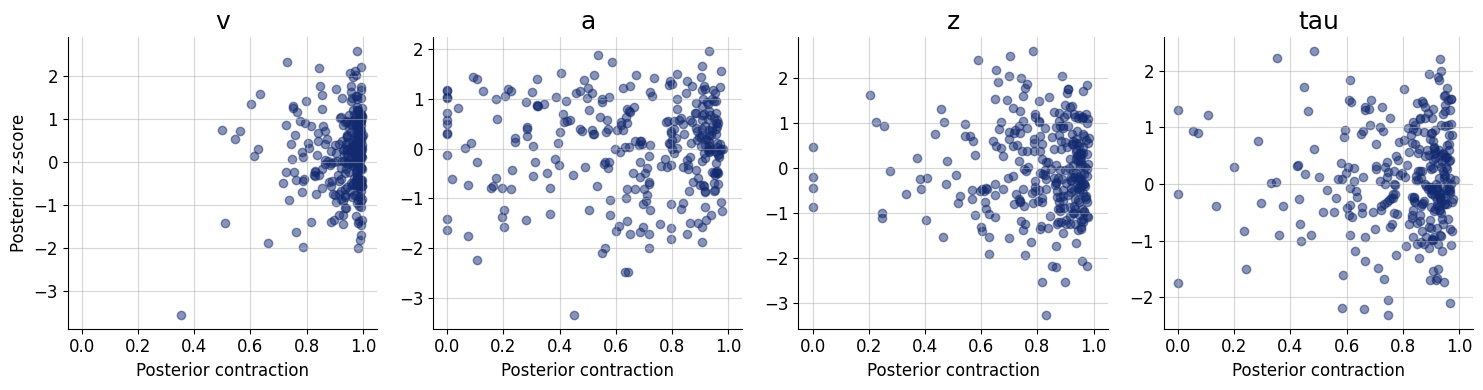

In [27]:
figures = workflow.plot_default_diagnostics(
    test_data=validation_data,
    loss_kwargs={"figsize": (15, 4), "label_fontsize": 12},
    recovery_kwargs={"figsize": (15, 4), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (15, 4), "legend_fontsize": 8, "difference": True, "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": (15, 4), "label_fontsize": 12}    
)

*Here, we describe what each of these plots means. From top to bottom:

1) **Loss Trajectory** records the training and validation losses per epoch for the neural estimator.
2) **Parameter Recovery** gives us a sense of whether the distribution from the generated posterior samples from the neural estimator is in agreement with the ground truth from the simulated dataset. This indicates the *global inferential accuracy* of the neural estimator.
3) **Rank ECDF** plots the expected cumulative distribution function (ECDF) for the rank statistics of the parameter samples. For a well-calibrated neural estimator, this function should fall entirely within the 95\% confidence bands for all parameters. For more detail, please take a look at [this paper about simulation-based calibration (SBC)](https://arxiv.org/abs/2103.10522).
4) **$z$-score contraction** does a similar job as parameter recovery in a sense that it tells us how well the posterior estimation is from the true parameter. For more detail, please take a look at [this page](https://betanalpha.github.io/assets/case_studies/principled_bayesian_workflow.html)

You can also easily get numerical versions for these diagnostics:

In [28]:
table = workflow.compute_default_diagnostics(test_data=validation_data)
table

,v,a,z,tau
NRMSE,0.052126,0.145818,0.143840,0.087236
Posterior Contraction,0.968270,0.718646,0.871985,0.864889
Calibration Error,0.033070,0.009649,0.030175,0.062632


**Congrats!** Now you have learned about the workflow from simulation to estimation through the inter-working between the SSM Simulator and BayesFlow!

# Further Topics

## Making the Simulator More Realistic

In [29]:
def extended_ddm_simulator(
    v: float, 
    a: float, 
    z: float, 
    tau: float, 
    num_trials: int = 100, 
    contam_prop: float = 0.05,
):
    """
    A simple wrapper of the standard Drift-Diffusion Model (DDM) simulator using the SSMS package. 
    It will simulate `num_trials` responses of synthetic participant with the provided parameters,
    including a proportion of contaminant trials with random RTs and choices.

    Parameters
    ----------
    v : float
        User-defined drift rate.
    a : float
        User-defined decision boundary threshold.
    z : float
        User-defined initial decision bias.
    tau : float
        User-defined non-decision time (NDT).
    num_trials : int, default: 100
        Number of simulated trials for the synthetic participant.
    contam_prop : float, default: 0.05
        Proportion of contaminant trials (random response trials).

    Returns
    -------
    dict
        A dictionary with:
        - 'rts': reaction times (np.ndarray, shape: [num_trials])
        - 'choices': choice outcomes (np.ndarray, shape: [num_trials])
    """

    # Simulate standard DDM trials
    ddm_sim = ssm_sim(model="ddm", theta=dict(v=v, a=a, z=z, t=tau), n_samples=num_trials)
    rts = np.array(ddm_sim['rts'])
    choices = np.array(ddm_sim['choices'])

    # Add contaminants
    n_contam = int(np.round(num_trials * contam_prop))
    if n_contam > 0:
        contam_idx = np.random.choice(num_trials, size=n_contam, replace=False)
        rts[contam_idx] = np.random.uniform(0, 20, size=n_contam)
        choices[contam_idx] = np.random.randint(0, 2, size=n_contam)

    return dict(rts=rts, choices=choices)

In [31]:
simulator = bf.make_simulator([priors, extended_ddm_simulator])